# Predicția Valorii de Piață a Jucătorilor FIFA 22

**Dataset:** FIFA 22 Complete Player Dataset (Kaggle — stefanoleone992)
**Sursă:** EA Sports FIFA 22
**Tip sarcină:** Predicție numerică (regresie)
**Variabila țintă:** `value_eur` — valoarea de piață în euro

---

## Procesul KDD
1. Selecția datelor
2. Preprocesarea datelor
3. Transformarea datelor
4. Selecția și antrenarea modelului
5. Evaluarea
6. Prezentarea rezultatelor

## 1. Încărcarea și Explorarea Inițială a Datelor

### 1.1 Importarea librăriilor

In [1]:
!pip install kagglehub[pandas-datasets] -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_theme(style="whitegrid")

print("Librăriile au fost importate cu succes.")

Librăriile au fost importate cu succes.


### 1.2 Încărcarea dataset-ului

In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "stefanoleone992/fifa-22-complete-player-dataset",
    "players_22.csv",
    pandas_kwargs={"low_memory": False}
)

print("Dataset încărcat cu succes.")
print(f"Rânduri: {df.shape[0]}")
print(f"Coloane: {df.shape[1]}")

/tmp/ipykernel_1583/3812736021.py:4: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'fifa-22-complete-player-dataset' dataset.
Dataset încărcat cu succes.
Rânduri: 19239
Coloane: 110


### 1.3 Primele înregistrări

In [3]:
df.head()

,sofifa_id,player_url,short_name,long_name,player_positions,overall,potential,value_eur,wage_eur,age,dob,height_cm,weight_kg,club_team_id,club_name,league_name,league_level,club_position,club_jersey_number,club_loaned_from,club_joined,club_contract_valid_until,nationality_id,nationality_name,nation_team_id,nation_position,nation_jersey_number,preferred_foot,weak_foot,skill_moves,international_reputation,work_rate,body_type,real_face,release_clause_eur,player_tags,player_traits,pace,shooting,passing,dribbling,defending,physic,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,attacking_volleys,skill_dribbling,skill_curve,skill_fk_accuracy,skill_long_passing,skill_ball_control,movement_acceleration,movement_sprint_speed,movement_agility,movement_reactions,movement_balance,power_shot_power,power_jumping,power_stamina,power_strength,power_long_shots,mentality_aggression,mentality_interceptions,mentality_positioning,mentality_vision,mentality_penalties,mentality_composure,defending_marking_awareness,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,goalkeeping_speed,ls,st,rs,lw,lf,cf,rf,rw,lam,cam,ram,lm,lcm,cm,rcm,rm,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb,gk,player_face_url,club_logo_url,club_flag_url,nation_logo_url,nation_flag_url
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,"RW, ST, CF",93,93,78000000.0,320000.0,34,1987-06-24,170,72,73.0,Paris Saint-Germain,French Ligue 1,1.0,RW,30.0,NaN,2021-08-10,2023.0,52,Argentina,1369.0,RW,10.0,Left,4,4,5,Medium/Low,Unique,Yes,144300000.0,"#Dribbler, #Distance Shooter, #FK Specialist, ...","Finesse Shot, Long Shot Taker (AI), Playmaker ...",85.0,92.0,91.0,95.0,34.0,65.0,85,95,70,91,88,96,93,94,91,96,91,80,91,94,95,86,68,72,69,94,44,40,93,95,75,96,20,35,24,6,11,15,14,8,NaN,89+3,89+3,89+3,92,93,93,93,92,93,93,93,91+2,87+3,87+3,87+3,91+2,66+3,64+3,64+3,64+3,66+3,61+3,50+3,50+3,50+3,61+3,19+3,https://cdn.sofifa.net/players/158/023/22_120.png,https://cdn.sofifa.net/teams/73/60.png,https://cdn.sofifa.net/flags/fr.png,https://cdn.sofifa.net/teams/1369/60.png,https://cdn.sofifa.net/flags/ar.png
1,188545,https://sofifa.com/player/188545/robert-lewand...,R. Lewandowski,Robert Lewandowski,ST,92,92,119500000.0,270000.0,32,1988-08-21,185,81,21.0,FC Bayern München,German 1. Bundesliga,1.0,ST,9.0,NaN,2014-07-01,2023.0,37,Poland,1353.0,RS,9.0,Right,4,4,5,High/Medium,Unique,Yes,197200000.0,"#Aerial Threat, #Distance Shooter, #Clinical F...","Solid Player, Finesse Shot, Outside Foot Shot,...",78.0,92.0,79.0,86.0,44.0,82.0,71,95,90,85,89,85,79,85,70,88,77,79,77,93,82,90,85,76,86,87,81,49,95,81,90,88,35,42,19,15,6,12,8,10,NaN,90+2,90+2,90+2,85,88,88,88,85,86+3,86+3,86+3,84+3,80+3,80+3,80+3,84+3,64+3,66+3,66+3,66+3,64+3,61+3,60+3,60+3,60+3,61+3,19+3,https://cdn.sofifa.net/players/188/545/22_120.png,https://cdn.sofifa.net/teams/21/60.png,https://cdn.sofifa.net/flags/de.png,https://cdn.sofifa.net/teams/1353/60.png,https://cdn.sofifa.net/flags/pl.png
2,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,"ST, LW",91,91,45000000.0,270000.0,36,1985-02-05,187,83,11.0,Manchester United,English Premier League,1.0,ST,7.0,NaN,2021-08-27,2023.0,38,Portugal,1354.0,ST,7.0,Right,4,5,5,High/Low,Unique,Yes,83300000.0,"#Aerial Threat, #Dribbler, #Distance Shooter, ...","Power Free-Kick, Flair, Long Shot Taker (AI), ...",87.0,94.0,80.0,88.0,34.0,75.0,87,95,90,80,86,88,81,84,77,88,85,88,86,94,74,94,95,77,77,93,63,29,95,76,88,95,24,32,24,7,11,15,14,11,NaN,90+1,90+1,90+1,88,89,89,89,88,86+3,86+3,86+3,86+3,78+3,78+3,78+3,86+3,63+3,59+3,59+3,59+3,63+3,60+3,53+3,53+3,53+3,60+3,20+3,https://cdn.sofifa.net/players/020/801/22_120.png,https://cdn.sofifa.net/teams/11/60.png,https://cdn.sofifa.net/flags/gb-eng.png,https://cdn.sofifa.net/teams/1354/60.png,https://cdn.sofifa.net/flags/pt.png


### 1.4 Informații generale

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19239 entries, 0 to 19238
Columns: 110 entries, sofifa_id to nation_flag_url
dtypes: float64(16), int64(44), object(50)
memory usage: 16.1+ MB


### 1.5 Verificarea variabilei țintă — value_eur

In [5]:
print("Există coloana value_eur:", "value_eur" in df.columns)
print(f"Valori lipsă în value_eur: {df['value_eur'].isna().sum()}")
print()
print("Statistici descriptive:")
print(df["value_eur"].describe())

Există coloana value_eur: True
Valori lipsă în value_eur: 74

Statistici descriptive:
count    1.916500e+04
mean     2.850452e+06
std      7.613700e+06
min      9.000000e+03
25%      4.750000e+05
50%      9.750000e+05
75%      2.000000e+06
max      1.940000e+08
Name: value_eur, dtype: float64


### 1.6 Distribuția value_eur — original vs. logaritmică

Distribuția originală este puternic asimetrică spre dreapta (skewed right).
Transformarea log1p produce o distribuție aproape normală, justificând
aplicarea ei pe variabila țintă înainte de antrenare.

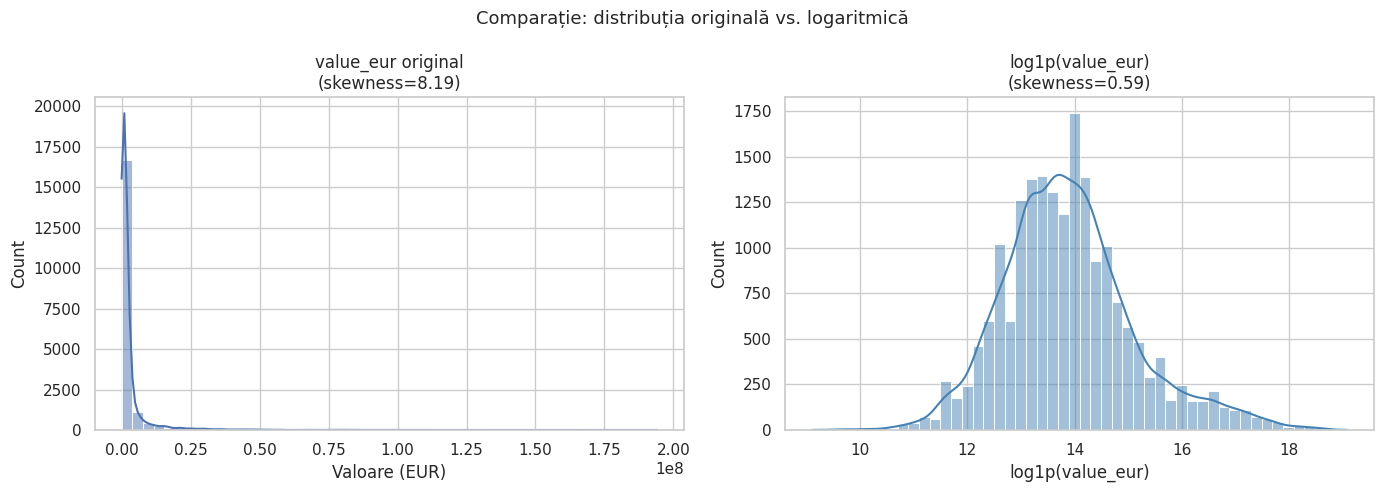

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["value_eur"].dropna(), bins=50, kde=True, ax=axes[0])
axes[0].set_title(f"value_eur original\n(skewness={df['value_eur'].skew():.2f})")
axes[0].set_xlabel("Valoare (EUR)")

sns.histplot(np.log1p(df["value_eur"].dropna()), bins=50, kde=True,
             color="steelblue", ax=axes[1])
axes[1].set_title(f"log1p(value_eur)\n(skewness={np.log1p(df['value_eur']).skew():.2f})")
axes[1].set_xlabel("log1p(value_eur)")

plt.suptitle("Comparație: distribuția originală vs. logaritmică", fontsize=13)
plt.tight_layout()
plt.show()

### 1.7 Valorile lipsă în dataset

In [7]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    "Valori lipsă": missing,
    "Procent (%)": missing_pct
}).sort_values("Valori lipsă", ascending=False)

print("Top 20 coloane cu valori lipsă:")
print(missing_df[missing_df["Valori lipsă"] > 0].head(20))

Top 20 coloane cu valori lipsă:
                      Valori lipsă  Procent (%)
nation_jersey_number         18480        96.05
nation_team_id               18480        96.05
nation_position              18480        96.05
nation_logo_url              18480        96.05
club_loaned_from             18137        94.27
player_tags                  17798        92.51
goalkeeping_speed            17107        88.92
player_traits                 9841        51.15
pace                          2132        11.08
physic                        2132        11.08
defending                     2132        11.08
dribbling                     2132        11.08
passing                       2132        11.08
shooting                      2132        11.08
release_clause_eur            1176         6.11
club_joined                   1163         6.05
value_eur                       74         0.38
league_name                     61         0.32
wage_eur                        61         0.32
league_l

### 1.8 Corelația cu value_eur — identificarea data leakage

release_clause_eur are corelație 0.995 cu value_eur deoarece
este calculată direct din valoarea de piață. Includerea ei
în model ar reprezenta data leakage și este exclusă explicit.

In [8]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

correlations = df[numeric_cols].corr(numeric_only=True)["value_eur"]\
               .sort_values(ascending=False)

print("Top 15 corelații cu value_eur:")
print(correlations.head(15))
print()
print(f"release_clause_eur corelație: {correlations['release_clause_eur']:.4f}")
print("=> Exclusă din proiect — DATA LEAKAGE")

Top 15 corelații cu value_eur:
value_eur                   1.000000
release_clause_eur          0.995460
wage_eur                    0.823527
international_reputation    0.632181
overall                     0.554684
potential                   0.527738
movement_reactions          0.492741
dribbling                   0.404812
passing                     0.404774
mentality_composure         0.389065
mentality_vision            0.324453
power_shot_power            0.301723
attacking_short_passing     0.297419
shooting                    0.290294
skill_long_passing          0.278721
Name: value_eur, dtype: float64

release_clause_eur corelație: 0.9955
=> Exclusă din proiect — DATA LEAKAGE


### 1.9 Heatmap — cele mai corelate variabile (fără release_clause_eur)

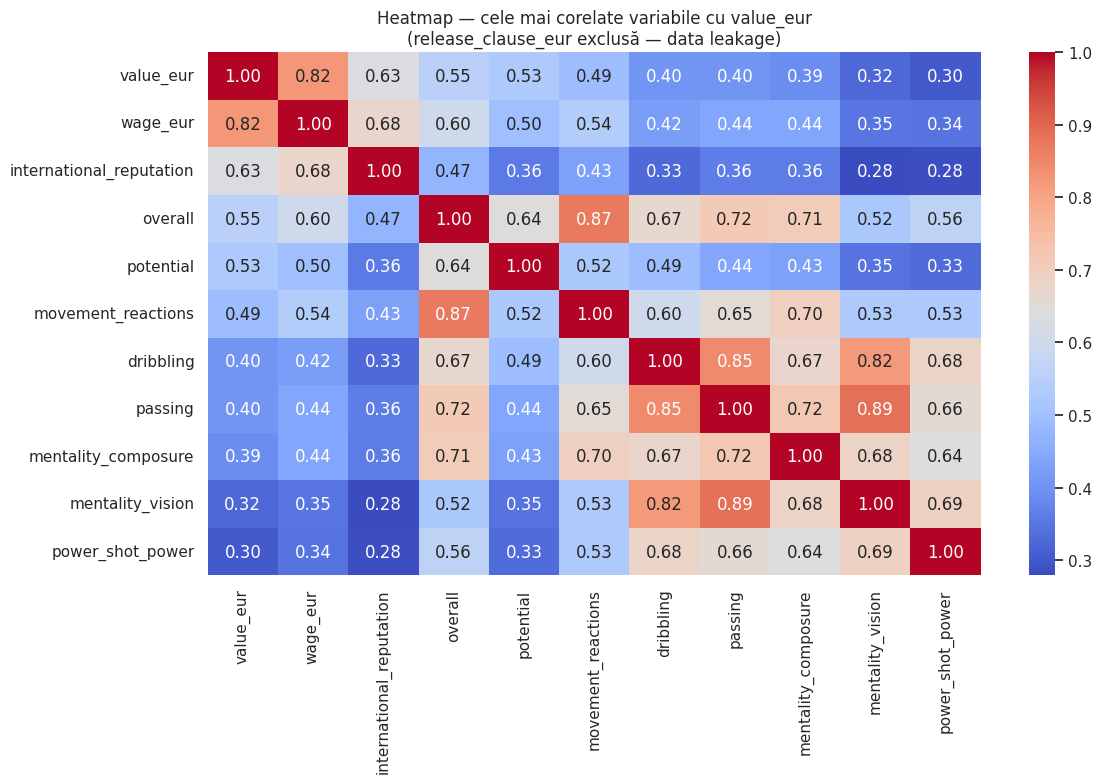

In [9]:
top_corr = correlations.drop("release_clause_eur").head(11).index

plt.figure(figsize=(12, 8))
sns.heatmap(df[top_corr].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Heatmap — cele mai corelate variabile cu value_eur\n"
          "(release_clause_eur exclusă — data leakage)")
plt.tight_layout()
plt.show()

### 1.10 Relația dintre overall și value_eur

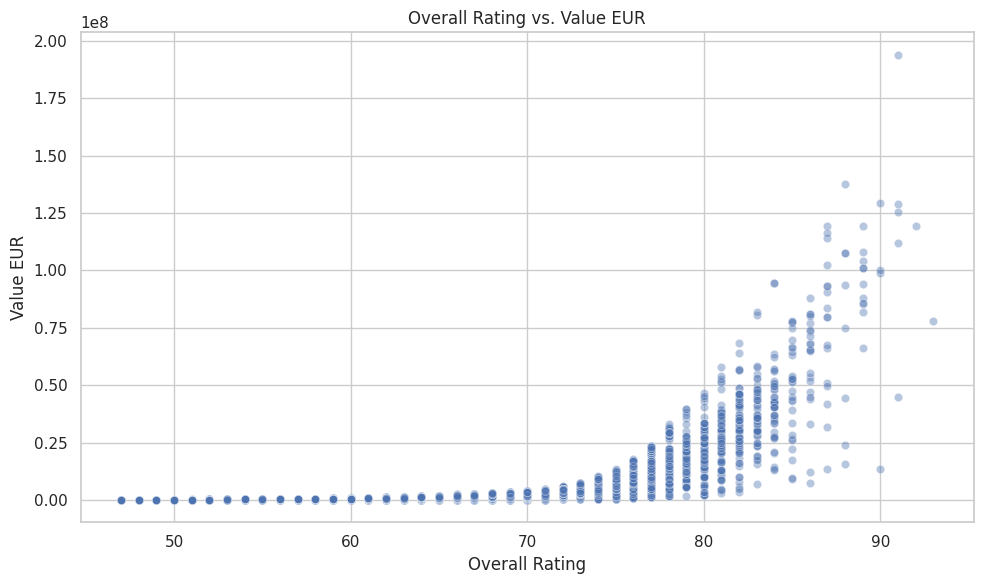

In [10]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="overall", y="value_eur", alpha=0.4)
plt.title("Overall Rating vs. Value EUR")
plt.xlabel("Overall Rating")
plt.ylabel("Value EUR")
plt.tight_layout()
plt.show()

### 1.11 Top 10 cei mai valoroși jucători

In [11]:
top10 = df[["short_name", "age", "club_name", "nationality_name",
            "overall", "potential", "value_eur", "wage_eur"]]\
        .sort_values("value_eur", ascending=False)\
        .head(10)\
        .reset_index(drop=True)

top10

,short_name,age,club_name,nationality_name,overall,potential,value_eur,wage_eur
0,K. Mbappé,22,Paris Saint-Germain,France,91,95,194000000.0,230000.0
1,E. Haaland,20,Borussia Dortmund,Norway,88,93,137500000.0,110000.0
2,H. Kane,27,Tottenham Hotspur,England,90,90,129500000.0,240000.0
3,Neymar Jr,29,Paris Saint-Germain,Brazil,91,91,129000000.0,270000.0
4,K. De Bruyne,30,Manchester City,Belgium,91,91,125500000.0,350000.0
5,G. Donnarumma,22,Paris Saint-Germain,Italy,89,93,119500000.0,110000.0
6,R. Lewandowski,32,FC Bayern München,Poland,92,92,119500000.0,270000.0
7,F. de Jong,24,FC Barcelona,Netherlands,87,92,119500000.0,210000.0
8,J. Sancho,21,Manchester United,England,87,91,116500000.0,150000.0
9,T. Alexander-Arnold,22,Liverpool,England,87,92,114000000.0,150000.0


## 2. Preprocesarea Datelor

### 2.1 Eliminarea rândurilor fără value_eur

In [12]:
print("Valori lipsă în value_eur:", df["value_eur"].isna().sum())
df = df.dropna(subset=["value_eur"])
print(f"Shape după eliminare: {df.shape}")

Valori lipsă în value_eur: 74
Shape după eliminare: (19165, 110)


### 2.2 Selectarea coloanelor relevante

Sunt selectate 21 de feature-uri reprezentând:
- Caracteristici fizice: age, height_cm, weight_kg
- Context: nationality_name, club_name, league_name
- Stil de joc: player_positions, preferred_foot, work_rate
- Rating FIFA: overall, potential, international_reputation
- Abilități: weak_foot, skill_moves
- Financiar: wage_eur
- Statistici tehnice: pace, shooting, passing, dribbling, defending, physic

release_clause_eur este exclusă explicit — corelație 0.995 cu
targetul reprezintă data leakage.

In [13]:
selected_features = [
    "age", "height_cm", "weight_kg",
    "nationality_name", "club_name", "league_name",
    "player_positions", "preferred_foot", "work_rate",
    "overall", "potential", "international_reputation",
    "weak_foot", "skill_moves",
    "wage_eur",
    "pace", "shooting", "passing", "dribbling", "defending", "physic"
]

target = "value_eur"
df_model = df[selected_features + [target]].copy()

print(f"Feature-uri selectate: {len(selected_features)}")
print(f"Shape df_model: {df_model.shape}")

Feature-uri selectate: 21
Shape df_model: (19165, 22)


### 2.3 Valorile lipsă în dataset-ul selectat

In [14]:
missing_sel = df_model.isna().sum().sort_values(ascending=False)
missing_pct = (missing_sel / len(df_model) * 100).round(2)

missing_df = pd.DataFrame({
    "Valori lipsă": missing_sel,
    "Procent (%)": missing_pct
})

print("Valori lipsă în dataset-ul selectat:")
print(missing_df[missing_df["Valori lipsă"] > 0])

Valori lipsă în dataset-ul selectat:
           Valori lipsă  Procent (%)
pace               2124        11.08
shooting           2124        11.08
physic             2124        11.08
defending          2124        11.08
passing            2124        11.08
dribbling          2124        11.08


### 2.4 Analiza și decizia privind outlierii

Outlierii din variabilele numerice sunt **păstrați** deoarece:
- Jucătorii cu valori extreme (Mbappé, Haaland) sunt reali și relevanți
- Eliminarea lor ar însemna antrenarea modelului fără cei mai valoroși jucători
- Modelele bazate pe arbori (Random Forest, Gradient Boosting) sunt robuste la outlieri
- Transformarea log1p aplicată pe target reduce impactul valorilor extreme

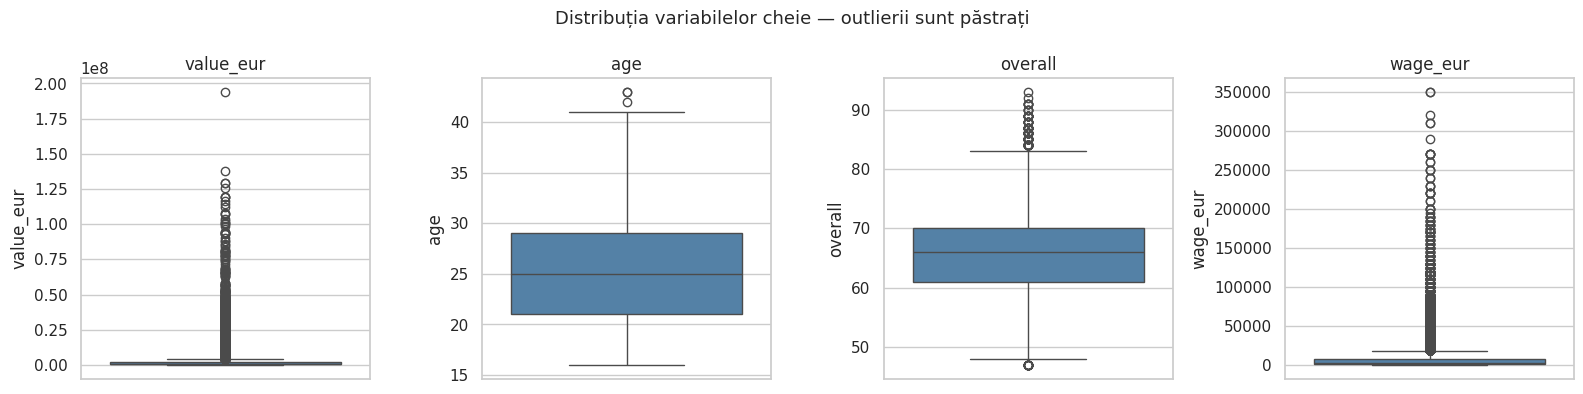

In [15]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, col in zip(axes, ["value_eur", "age", "overall", "wage_eur"]):
    sns.boxplot(y=df_model[col], ax=ax, color="steelblue")
    ax.set_title(col)

plt.suptitle("Distribuția variabilelor cheie — outlierii sunt păstrați",
             fontsize=13)
plt.tight_layout()
plt.show()

### 2.5 Eliminarea duplicatelor și valorilor invalide din target

In [16]:
inainte = df_model.shape[0]
df_model = df_model.drop_duplicates()
print(f"Duplicate eliminate: {inainte - df_model.shape[0]}")

df_model = df_model[df_model["value_eur"] > 0]
print(f"Shape final: {df_model.shape}")

Duplicate eliminate: 0
Shape final: (19165, 22)


### 2.6 Salvarea dataset-ului curățat

In [17]:
df_clean = df_model.copy()

print(f"Dataset curățat salvat în df_clean.")
print(f"Shape: {df_clean.shape}")
print()
print(f"Skewness value_eur original:  {df_clean['value_eur'].skew():.2f}")
print(f"Skewness log1p(value_eur):    {np.log1p(df_clean['value_eur']).skew():.2f}")
print()
print("Transformarea log1p va fi aplicată la pasul 3.")

Dataset curățat salvat în df_clean.
Shape: (19165, 22)

Skewness value_eur original:  8.19
Skewness log1p(value_eur):    0.59

Transformarea log1p va fi aplicată la pasul 3.


## 3. Transformarea Datelor și Împărțirea Seturilor

### 3.1 Separarea X și y — aplicarea transformării log1p

Variabila țintă value_eur are skewness 8.19 — distribuție puternic
asimetrică. Transformarea log1p(x) = log(1 + x):
- Face distribuția aproape normală (skewness 0.59)
- Reduce influența outlierilor asupra funcției de cost
- Îmbunătățește performanța regresiei liniare
- Inversă: expm1(y) = exp(y) - 1, aplicată la evaluare

In [18]:
X = df_clean.drop(columns=["value_eur"])
y = np.log1p(df_clean["value_eur"])

print("Shape X:", X.shape)
print("Shape y (log1p):", y.shape)
print(f"Skewness y: {y.skew():.2f}")

Shape X: (19165, 21)
Shape y (log1p): (19165,)
Skewness y: 0.59


### 3.2 Împărțirea în Train (70%) / Validare (15%) / Test (15%)

Rolul fiecărui set:
- **Train (70%)**: estimarea parametrilor modelului
- **Validare (15%)**: alegerea hiperparametrilor și compararea modelelor
- **Test (15%)**: evaluarea finală — folosit o singură dată, la final

X_trainval (85%) va fi folosit la KDD Pasul 8 pentru
reantrenarea modelului final înainte de evaluarea pe test.

In [19]:
from sklearn.model_selection import train_test_split

# Split 1: 15% test, 85% train+val
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)

# Split 2: din 85%, ~17.6% val → 15% din total
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.176, random_state=42
)

n = len(X)
print("Distribuția seturilor:")
print(f"  Train:    {len(X_train):>5} ({len(X_train)/n*100:.1f}%)")
print(f"  Validare: {len(X_val):>5} ({len(X_val)/n*100:.1f}%)")
print(f"  Test:     {len(X_test):>5} ({len(X_test)/n*100:.1f}%)")
print(f"  Total:    {n:>5} (100%)")

Distribuția seturilor:
  Train:    13422 (70.0%)
  Validare:  2868 (15.0%)
  Test:      2875 (15.0%)
  Total:    19165 (100%)


### 3.3 Identificarea coloanelor numerice și categorice

In [20]:
numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(
    include=["object"]).columns.tolist()

print(f"Numerice ({len(numeric_features)}):   {numeric_features}")
print(f"\nCategorice ({len(categorical_features)}): {categorical_features}")

Numerice (15):   ['age', 'height_cm', 'weight_kg', 'overall', 'potential', 'international_reputation', 'weak_foot', 'skill_moves', 'wage_eur', 'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic']

Categorice (6): ['nationality_name', 'club_name', 'league_name', 'player_positions', 'preferred_foot', 'work_rate']


### 3.4 Funcția create_preprocessor() — preprocessor independent per pipeline

Proiectul inițial partaja același obiect preprocessor între toate
cele 3 pipeline-uri, ceea ce ducea la suprascrierea stării interne.
Soluție: create_preprocessor() returnează o instanță nouă la fiecare apel.

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

def create_preprocessor(num_cols, cat_cols):
    """
    Returnează un ColumnTransformer nou la fiecare apel.
    Numeric:   imputare mediană + StandardScaler
    Categoric: imputare mod + OneHotEncoder
    """
    num_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler())
    ])
    cat_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot",  OneHotEncoder(handle_unknown="ignore"))
    ])
    return ColumnTransformer(transformers=[
        ("num", num_pipeline, num_cols),
        ("cat", cat_pipeline, cat_cols)
    ])

print("create_preprocessor() definit.")
print("Fiecare pipeline va primi o instanță independentă.")

create_preprocessor() definit.
Fiecare pipeline va primi o instanță independentă.


## 4. Selecția Variabilelor

Includerea variabilelor irelevante poate duce la overfitting,
dificultăți de interpretare și ineficiență computațională.

**Strategie**: Antrenăm un Random Forest preliminar exclusiv pe
datele de training, extragem importanța variabilelor originale
și selectăm variabilele cu importanță peste un prag stabilit.

### 4.1 Antrenarea Random Forest preliminar

In [22]:
from sklearn.ensemble import RandomForestRegressor

rf_prelim = Pipeline(steps=[
    ("preprocessor", create_preprocessor(numeric_features, categorical_features)),
    ("model", RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

rf_prelim.fit(X_train, y_train)
print("Random Forest preliminar antrenat pe X_train.")

Random Forest preliminar antrenat pe X_train.


### 4.2 Extragerea și agregarea importanței per variabilă originală

OneHotEncoding expandează fiecare variabilă categorică în multiple
coloane binare. Agregăm importanțele sub-coloanelor pentru a obține
importanța variabilei originale.

In [23]:
def get_original_feature(enc_name, num_cols, cat_cols):
    if enc_name.startswith("num__"):
        return enc_name[5:]
    elif enc_name.startswith("cat__"):
        stripped = enc_name[5:]
        for col in cat_cols:
            if stripped.startswith(col + "_") or stripped == col:
                return col
        return stripped
    return enc_name

encoded_names   = rf_prelim.named_steps["preprocessor"].get_feature_names_out()
importances_raw = rf_prelim.named_steps["model"].feature_importances_

agg_importances = {}
for enc_name, imp in zip(encoded_names, importances_raw):
    orig = get_original_feature(enc_name, numeric_features, categorical_features)
    agg_importances[orig] = agg_importances.get(orig, 0) + imp

feat_imp_df = pd.DataFrame({
    "Variabila":  list(agg_importances.keys()),
    "Importanta": list(agg_importances.values())
}).sort_values("Importanta", ascending=False).reset_index(drop=True)

print("Importanța variabilelor originale:")
print(feat_imp_df)

Importanța variabilelor originale:
                   Variabila  Importanta
0                    overall    0.754776
1                  potential    0.181372
2                        age    0.050311
3                skill_moves    0.003790
4           player_positions    0.003503
5                   shooting    0.001610
6                  dribbling    0.001195
7                  defending    0.001090
8                   wage_eur    0.000368
9                    passing    0.000364
10                      pace    0.000238
11                 club_name    0.000226
12          nationality_name    0.000217
13                 height_cm    0.000202
14                 weight_kg    0.000193
15                    physic    0.000179
16               league_name    0.000160
17                 work_rate    0.000090
18                 weak_foot    0.000060
19            preferred_foot    0.000028
20  international_reputation    0.000028


### 4.3 Vizualizarea importanței și selectarea variabilelor

Pragul mediu elimină prea multe variabile deoarece overall
domină distribuția. Folosim un prag fix de 0.001 pentru a
păstra variabilele cu contribuție reală.

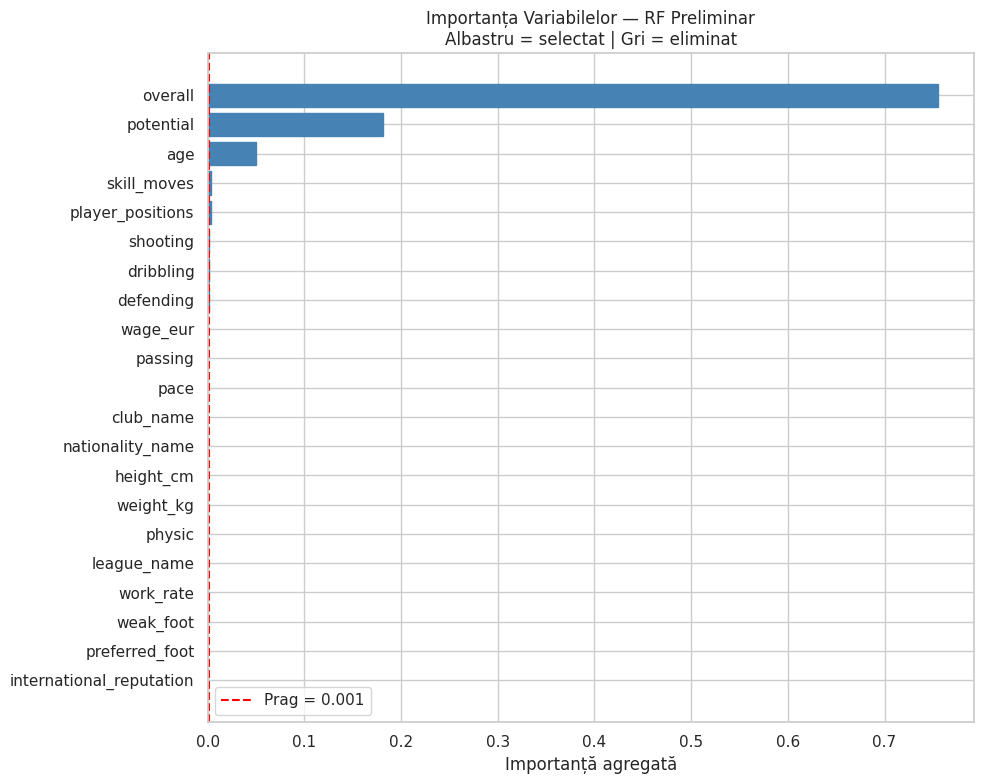

Prag: 0.001

Variabile SELECTATE (8):
  overall                   0.7548
  potential                 0.1814
  age                       0.0503
  skill_moves               0.0038
  player_positions          0.0035
  shooting                  0.0016
  dribbling                 0.0012
  defending                 0.0011

Variabile ELIMINATE (13):
  wage_eur                  0.0004
  passing                   0.0004
  pace                      0.0002
  club_name                 0.0002
  nationality_name          0.0002
  height_cm                 0.0002
  weight_kg                 0.0002
  physic                    0.0002
  league_name               0.0002
  work_rate                 0.0001
  weak_foot                 0.0001
  preferred_foot            0.0000
  international_reputation  0.0000


In [24]:
threshold_imp = 0.001

selected_vars = feat_imp_df[
    feat_imp_df["Importanta"] >= threshold_imp
]["Variabila"].tolist()

eliminated_vars = feat_imp_df[
    feat_imp_df["Importanta"] < threshold_imp
]["Variabila"].tolist()

# Vizualizare
colors_imp = ["steelblue" if imp >= threshold_imp else "#cccccc"
              for imp in feat_imp_df["Importanta"]]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(feat_imp_df["Variabila"][::-1],
               feat_imp_df["Importanta"][::-1])
for bar, color in zip(bars, reversed(colors_imp)):
    bar.set_color(color)
ax.axvline(x=threshold_imp, color="red", linestyle="--",
           label=f"Prag = {threshold_imp}")
ax.set_xlabel("Importanță agregată")
ax.set_title("Importanța Variabilelor — RF Preliminar\n"
             "Albastru = selectat | Gri = eliminat")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Prag: {threshold_imp}")
print(f"\nVariabile SELECTATE ({len(selected_vars)}):")
for v in selected_vars:
    imp = feat_imp_df.loc[feat_imp_df["Variabila"]==v, "Importanta"].values[0]
    print(f"  {v:<25} {imp:.4f}")

print(f"\nVariabile ELIMINATE ({len(eliminated_vars)}):")
for v in eliminated_vars:
    imp = feat_imp_df.loc[feat_imp_df["Variabila"]==v, "Importanta"].values[0]
    print(f"  {v:<25} {imp:.4f}")

### 4.4 Filtrarea seturilor de date

In [25]:
X_train_sel    = X_train[selected_vars]
X_val_sel      = X_val[selected_vars]
X_test_sel     = X_test[selected_vars]
X_trainval_sel = X_trainval[selected_vars]

num_sel = X_train_sel.select_dtypes(
    include=["int64","float64"]).columns.tolist()
cat_sel = X_train_sel.select_dtypes(
    include=["object"]).columns.tolist()

print(f"Variabile selectate total: {len(selected_vars)}")
print(f"  Numerice:   {num_sel}")
print(f"  Categorice: {cat_sel}")
print()
print(f"X_train_sel:    {X_train_sel.shape}")
print(f"X_val_sel:      {X_val_sel.shape}")
print(f"X_test_sel:     {X_test_sel.shape}")
print(f"X_trainval_sel: {X_trainval_sel.shape}")

Variabile selectate total: 8
  Numerice:   ['overall', 'potential', 'age', 'skill_moves', 'shooting', 'dribbling', 'defending']
  Categorice: ['player_positions']

X_train_sel:    (13422, 8)
X_val_sel:      (2868, 8)
X_test_sel:     (2875, 8)
X_trainval_sel: (16290, 8)


## 5. Antrenarea Modelelor

### 5.1 Importuri și funcția de evaluare

Funcția evaluate_model calculează metricile în scala EUR
după back-transformarea predicțiilor cu expm1.
Metrici: MAE, MSE, RMSE, R²

In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, GridSearchCV

def evaluate_model(model_name, model, X_eval, y_eval_log, set_name=""):
    """
    Evaluează un model și returnează MAE, MSE, RMSE, R² în scala EUR.
    Parametri:
        model_name  : numele modelului
        model       : pipeline sklearn antrenat
        X_eval      : features
        y_eval_log  : target transformat cu log1p
        set_name    : 'Train' / 'Validare' / 'Test'
    """
    y_pred_log = model.predict(X_eval)
    y_true_eur = np.expm1(np.array(y_eval_log))
    y_pred_eur = np.clip(np.expm1(y_pred_log), 0, None)

    mae  = mean_absolute_error(y_true_eur, y_pred_eur)
    mse  = mean_squared_error(y_true_eur, y_pred_eur)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true_eur, y_pred_eur)

    label = f"{model_name} [{set_name}]" if set_name else model_name
    print(f"\n{'─'*55}")
    print(f"  {label}")
    print(f"{'─'*55}")
    print(f"  MAE  : {mae:>15,.2f} EUR")
    print(f"  MSE  : {mse:>15,.2f} EUR²")
    print(f"  RMSE : {rmse:>15,.2f} EUR")
    print(f"  R²   : {r2:>15.4f}")

    return {"Model": model_name, "Set": set_name,
            "MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}

print("evaluate_model() definit.")

evaluate_model() definit.


### 5.2 Modelul 1 — Regresia Liniară (baseline)

Regresie liniară multivariată cu **{len(selected_vars)} predictori**
(număr determinat dinamic după selecția variabilelor din secțiunea 4):

log1p(value_eur) = w₀ + w₁·X₁ + w₂·X₂ + ... + wₚ·Xₚ

LinearRegression nu are hiperparametri de optimizat — estimare directă OLS.
Servește drept model baseline pentru compararea cu modelele mai complexe.

In [27]:
linear_model = Pipeline(steps=[
    ("preprocessor", create_preprocessor(num_sel, cat_sel)),
    ("model", LinearRegression())
])

# Cross-validare 5-fold pe training
cv_r2_linear = cross_val_score(
    Pipeline(steps=[
        ("preprocessor", create_preprocessor(num_sel, cat_sel)),
        ("model", LinearRegression())
    ]),
    X_train_sel, y_train, cv=5, scoring="r2", n_jobs=-1
)
print(f"Predictori folosiți: {len(selected_vars)}")
print(f"CV R² (5-fold): {cv_r2_linear.mean():.4f} ± {cv_r2_linear.std():.4f}")

linear_model.fit(X_train_sel, y_train)

linear_train = evaluate_model("Linear Regression", linear_model,
                               X_train_sel, y_train, "Train")
linear_val   = evaluate_model("Linear Regression", linear_model,
                               X_val_sel, y_val, "Validare")

Predictori folosiți: 8
CV R² (5-fold): 0.9634 ± 0.0010

───────────────────────────────────────────────────────
  Linear Regression [Train]
───────────────────────────────────────────────────────
  MAE  :      647,443.60 EUR
  MSE  : 5,695,415,291,319.59 EUR²
  RMSE :    2,386,506.92 EUR
  R²   :          0.9027

───────────────────────────────────────────────────────
  Linear Regression [Validare]
───────────────────────────────────────────────────────
  MAE  :      740,609.95 EUR
  MSE  : 7,231,799,209,056.56 EUR²
  RMSE :    2,689,200.48 EUR
  R²   :          0.8701


### 5.2.1 Ecuația regresiei liniare — coeficienții modelului

Coeficientul wᵢ reprezintă variația log1p(value_eur) la
creșterea Xᵢ cu o unitate, ceilalți predictori rămânând constanți.

Interceptul (w₀): 13.9064

Regresie liniară multivariată cu 8 predictori originali
(607 coloane după One-Hot Encoding)

Top 10 coeficienți (după valoare absolută):
                          Feature  Coeficient
                     num__overall    1.298632
 cat__player_positions_CF, RM, RW    0.673402
 cat__player_positions_CM, LM, CF    0.592831
                         num__age   -0.555834
     cat__player_positions_CF, LW    0.539905
cat__player_positions_CDM, RB, RM   -0.496462
 cat__player_positions_CB, RB, CM   -0.487903
cat__player_positions_CF, LW, CAM    0.482867
cat__player_positions_RWB, RM, LM    0.454670
     cat__player_positions_CF, CM    0.451216

Ecuația (predictori numerici principali):
log1p(value_eur) = 13.9064 + (+1.2986)·overall + (-0.5558)·age + (+0.0492)·defending + (+0.0399)·skill_moves + (+0.0186)·shooting + ...


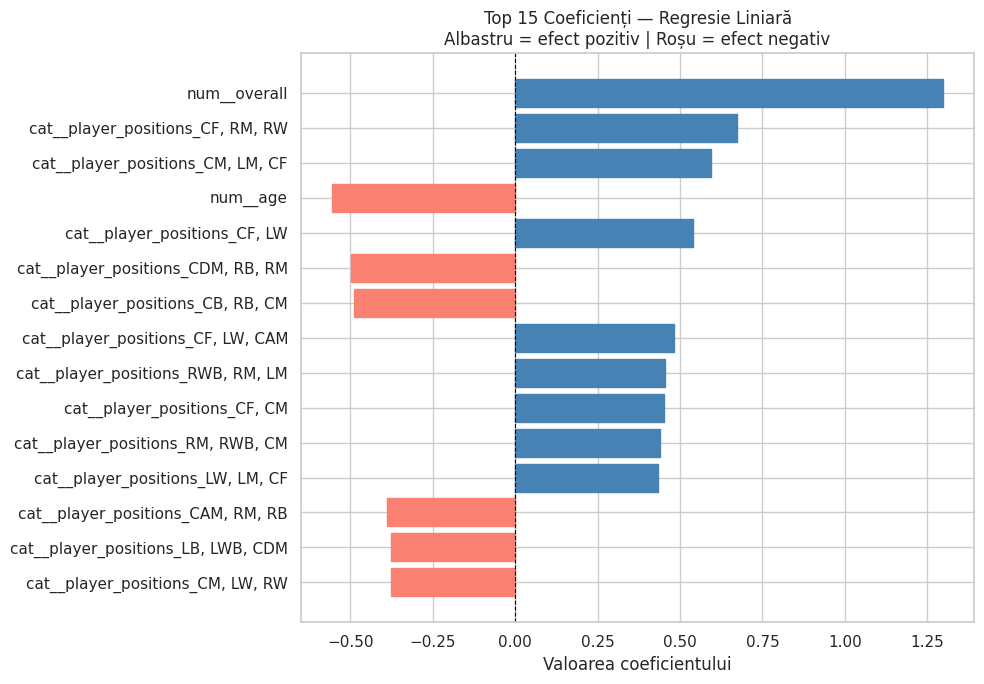

In [28]:
lr_coef       = linear_model.named_steps["model"].coef_
lr_intercept  = linear_model.named_steps["model"].intercept_
lr_feat_names = linear_model.named_steps["preprocessor"].get_feature_names_out()

coef_df = pd.DataFrame({
    "Feature":    lr_feat_names,
    "Coeficient": lr_coef
}).sort_values("Coeficient", key=abs, ascending=False).reset_index(drop=True)

print(f"Interceptul (w₀): {lr_intercept:.4f}")
print(f"\nRegresie liniară multivariată cu {len(selected_vars)} predictori originali")
print(f"({len(lr_feat_names)} coloane după One-Hot Encoding)\n")
print("Top 10 coeficienți (după valoare absolută):")
print(coef_df.head(10).to_string(index=False))

# Ecuatia compacta cu top 5 termeni numerici
numeric_coefs = coef_df[coef_df["Feature"].str.startswith("num__")].head(5)
termeni = " + ".join(
    f"({r['Coeficient']:+.4f})·{r['Feature'].replace('num__','')}"
    for _, r in numeric_coefs.iterrows()
)
print(f"\nEcuația (predictori numerici principali):")
print(f"log1p(value_eur) = {lr_intercept:.4f} + {termeni} + ...")

# Grafic top 15 coeficienti
top15 = coef_df.head(15).copy()
colors_coef = ["steelblue" if c > 0 else "salmon" for c in top15["Coeficient"]]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top15["Feature"][::-1], top15["Coeficient"][::-1])
for bar, color in zip(bars, reversed(colors_coef)):
    bar.set_color(color)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Valoarea coeficientului")
ax.set_title(f"Top 15 Coeficienți — Regresie Liniară\n"
             f"Albastru = efect pozitiv | Roșu = efect negativ")
plt.tight_layout()
plt.show()

# functia regresiei liniare:
# log1p(value_eur) = 13.9064 + (+1.2986)·overall + (-0.5558)·age + (+0.0492)·defending + (+0.0399)·skill_moves + (+0.0186)·shooting + ...

### 5.3 Modelul 2 — Random Forest Regressor

Construiește arbori decizionali pe subseturi aleatorii ale datelor
și predictorilor, agregând predicțiile prin medie (FBD_4).
Scop principal: reducerea varianței.

Hiperparametri optimizați prin GridSearchCV (grid redus pentru viteză):
- n_estimators: numărul de arbori
- max_depth: adâncimea maximă
- min_samples_leaf: număr minim observații per frunză

In [29]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", create_preprocessor(num_sel, cat_sel)),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

rf_param_grid = {
    "model__n_estimators":    [50, 100, 200],
    "model__max_depth":       [10, 20, None],
    "model__min_samples_leaf":[1, 5]
}

print("GridSearchCV — Random Forest (18 combinații x 3-fold CV)...")
rf_grid_search = GridSearchCV(
    rf_pipeline, rf_param_grid,
    cv=3, scoring="r2", n_jobs=-1, verbose=1
)
rf_grid_search.fit(X_train_sel, y_train)

print(f"\nCei mai buni parametri: {rf_grid_search.best_params_}")
print(f"Cel mai bun R² CV:      {rf_grid_search.best_score_:.4f}")

GridSearchCV — Random Forest (18 combinații x 3-fold CV)...
Fitting 3 folds for each of 18 candidates, totalling 54 fits

Cei mai buni parametri: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 200}
Cel mai bun R² CV:      0.9981


### 5.3.1 OOB Error — justificarea numărului de arbori (FBD_4)

Training error scade continuu pe măsură ce adăugăm arbori.
OOB error estimează performanța reală și se stabilizează
după un anumit număr de arbori — alegem acel punct.

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


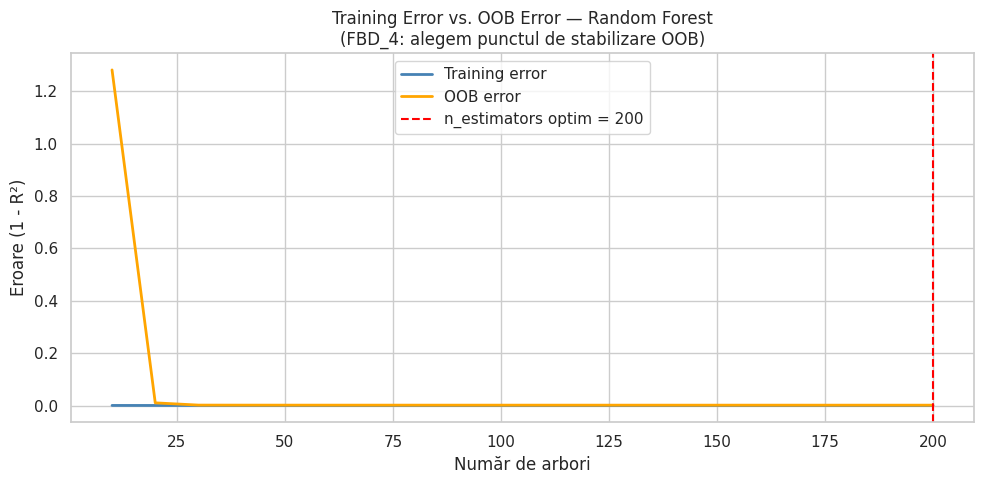

In [30]:
best_rf_params = {
    k.replace("model__", ""): v
    for k, v in rf_grid_search.best_params_.items()
}

preprocessor_oob = create_preprocessor(num_sel, cat_sel)
X_train_enc = preprocessor_oob.fit_transform(X_train_sel)

n_tree_range = range(10, 210, 10)
oob_errors   = []
train_errors = []

for n_trees in n_tree_range:
    rf_oob = RandomForestRegressor(
        n_estimators=n_trees,
        max_depth=best_rf_params["max_depth"],
        min_samples_leaf=best_rf_params["min_samples_leaf"],
        oob_score=True,
        random_state=42,
        n_jobs=-1
    )
    rf_oob.fit(X_train_enc, y_train)
    oob_errors.append(1 - rf_oob.oob_score_)
    train_errors.append(1 - rf_oob.score(X_train_enc, y_train))

plt.figure(figsize=(10, 5))
plt.plot(list(n_tree_range), train_errors,
         color="steelblue", linewidth=2, label="Training error")
plt.plot(list(n_tree_range), oob_errors,
         color="orange", linewidth=2, label="OOB error")
plt.axvline(x=best_rf_params["n_estimators"], color="red",
            linestyle="--", label=f"n_estimators optim = {best_rf_params['n_estimators']}")
plt.title("Training Error vs. OOB Error — Random Forest\n"
          "(FBD_4: alegem punctul de stabilizare OOB)")
plt.xlabel("Număr de arbori")
plt.ylabel("Eroare (1 - R²)")
plt.legend()
plt.tight_layout()
plt.show()

### 5.3.2 Learning Curve — eroare train vs. validare pe număr de arbori

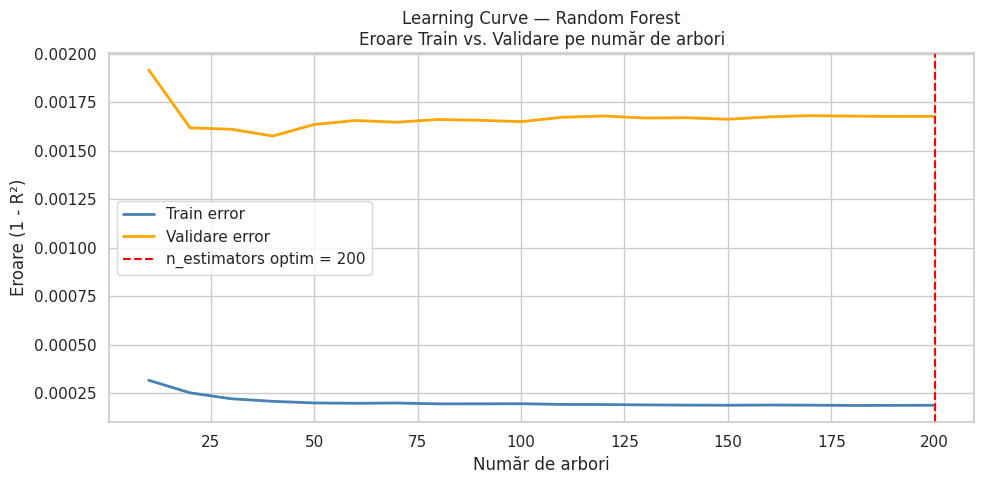

In [31]:
preprocessor_lc = create_preprocessor(num_sel, cat_sel)
X_train_enc_lc  = preprocessor_lc.fit_transform(X_train_sel)
X_val_enc_lc    = preprocessor_lc.transform(X_val_sel)

train_errors_lc = []
val_errors_lc   = []

for n_trees in n_tree_range:
    rf_lc = RandomForestRegressor(
        n_estimators=n_trees,
        max_depth=best_rf_params["max_depth"],
        min_samples_leaf=best_rf_params["min_samples_leaf"],
        random_state=42,
        n_jobs=-1
    )
    rf_lc.fit(X_train_enc_lc, y_train)
    train_errors_lc.append(1 - rf_lc.score(X_train_enc_lc, y_train))
    val_errors_lc.append(1 - rf_lc.score(X_val_enc_lc, y_val))

plt.figure(figsize=(10, 5))
plt.plot(list(n_tree_range), train_errors_lc,
         color="steelblue", linewidth=2, label="Train error")
plt.plot(list(n_tree_range), val_errors_lc,
         color="orange", linewidth=2, label="Validare error")
plt.axvline(x=best_rf_params["n_estimators"], color="red",
            linestyle="--", label=f"n_estimators optim = {best_rf_params['n_estimators']}")
plt.title("Learning Curve — Random Forest\nEroare Train vs. Validare pe număr de arbori")
plt.xlabel("Număr de arbori")
plt.ylabel("Eroare (1 - R²)")
plt.legend()
plt.tight_layout()
plt.show()

### 5.3.3 Reantrenare cu max_depth=10 (cerință profesor)

GridSearchCV a selectat max_depth=None, însă conform cerințelor
proiectului impunem max_depth=10 pentru a reduce overfitting-ul
vizibil în learning curve. Păstrăm ceilalți parametri optimi
identificați de GridSearchCV.

In [32]:
# Suprascriem parametrii conform analizei overfitting
best_rf_params_final = {
    "n_estimators":    300,   # crescut pentru stabilitate
    "max_depth":       8,     # redus fata de 10 pentru a limita overfitting
    "min_samples_leaf": 10    # crescut fata de 1 pentru generalizare mai buna
}

print("Parametri finali Random Forest (ajustati pentru reducerea overfitting):")
print(best_rf_params_final)
print()
print("Justificare:")
print("  max_depth 10 → 8:    arbori mai putin profunzi, mai putina memorare")
print("  min_samples_leaf 1 → 10: frunze mai 'groase', generalizare mai buna")
print("  n_estimators 200 → 300: mai multi arbori pentru stabilitate")

# CV 5-fold cu parametrii ajustati
cv_r2_rf = cross_val_score(
    Pipeline(steps=[
        ("preprocessor", create_preprocessor(num_sel, cat_sel)),
        ("model", RandomForestRegressor(**best_rf_params_final,
                                        random_state=42, n_jobs=-1))
    ]),
    X_train_sel, y_train, cv=5, scoring="r2", n_jobs=-1
)
print(f"\nCV R² (5-fold): {cv_r2_rf.mean():.4f} ± {cv_r2_rf.std():.4f}")

# Antrenare model final RF cu parametrii ajustati
random_forest_model = Pipeline(steps=[
    ("preprocessor", create_preprocessor(num_sel, cat_sel)),
    ("model", RandomForestRegressor(**best_rf_params_final,
                                    random_state=42, n_jobs=-1))
])
random_forest_model.fit(X_train_sel, y_train)

# Evaluare train si validare
rf_train = evaluate_model("Random Forest", random_forest_model,
                           X_train_sel, y_train, "Train")
rf_val   = evaluate_model("Random Forest", random_forest_model,
                           X_val_sel, y_val, "Validare")

Parametri finali Random Forest:
{'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 200}

CV R² (5-fold): 0.9974 ± 0.0003

───────────────────────────────────────────────────────
  Random Forest [Train]
───────────────────────────────────────────────────────
  MAE  :      105,167.31 EUR
  MSE  : 263,013,447,133.89 EUR²
  RMSE :      512,848.37 EUR
  R²   :          0.9955

───────────────────────────────────────────────────────
  Random Forest [Validare]
───────────────────────────────────────────────────────
  MAE  :      157,374.58 EUR
  MSE  : 930,056,345,111.79 EUR²
  RMSE :      964,394.29 EUR
  R²   :          0.9833


### 5.4 Modelul 3 — Gradient Boosting Regressor

Construiește arbori SECVENȚIAL, fiecare corectând erorile
modelului anterior prin antrenare pe reziduuri. (FBD_4)
Scop principal: reducerea bias-ului.

Hiperparametri optimizați prin GridSearchCV (grid redus):
- n_estimators: numărul de iterații
- learning_rate: contribuția fiecărui arbore
- max_depth: adâncimea arborilor slabi
- min_samples_leaf: număr minim observații per frunză

In [33]:
gb_pipeline = Pipeline(steps=[
    ("preprocessor", create_preprocessor(num_sel, cat_sel)),
    ("model", GradientBoostingRegressor(random_state=42))
])

gb_param_grid = {
    "model__n_estimators":    [100, 200],
    "model__learning_rate":   [0.05, 0.1],
    "model__max_depth":       [3, 5],
    "model__min_samples_leaf":[1, 5]
}

print("GridSearchCV — Gradient Boosting (16 combinații x 3-fold CV)...")
gb_grid_search = GridSearchCV(
    gb_pipeline, gb_param_grid,
    cv=3, scoring="r2", n_jobs=-1, verbose=1
)
gb_grid_search.fit(X_train_sel, y_train)

print(f"\nCei mai buni parametri: {gb_grid_search.best_params_}")
print(f"Cel mai bun R² CV:      {gb_grid_search.best_score_:.4f}")

GridSearchCV — Gradient Boosting (16 combinații x 3-fold CV)...
Fitting 3 folds for each of 16 candidates, totalling 48 fits

Cei mai buni parametri: {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__min_samples_leaf': 5, 'model__n_estimators': 200}
Cel mai bun R² CV:      0.9980


### 5.4.1 Learning Curve — eroare train vs. validare pe număr de iterații

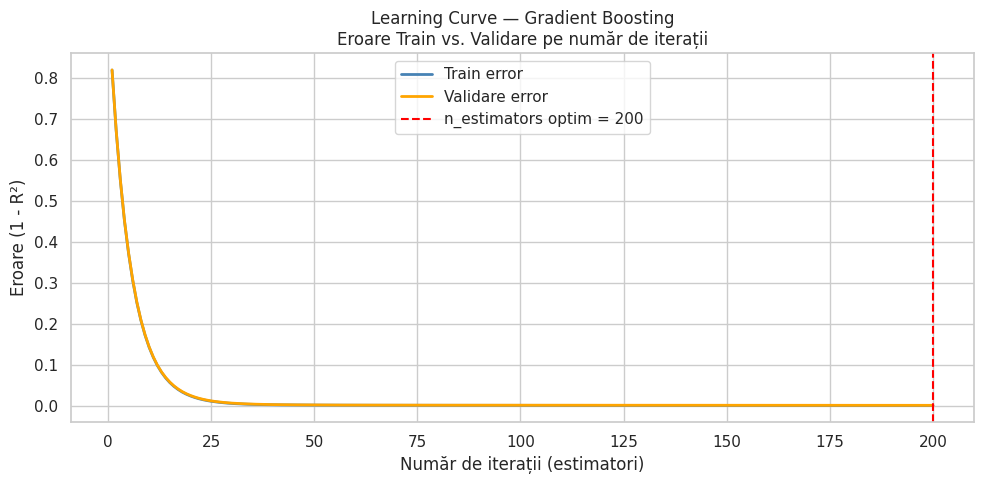

Iterația cu eroare minimă pe validare: 200
Eroare validare la iterația optimă:    0.001591


In [34]:
best_gb_params = {
    k.replace("model__", ""): v
    for k, v in gb_grid_search.best_params_.items()
}

preprocessor_gb_lc = create_preprocessor(num_sel, cat_sel)
X_train_enc_gb = preprocessor_gb_lc.fit_transform(X_train_sel)
X_val_enc_gb   = preprocessor_gb_lc.transform(X_val_sel)

# Antrenam GB cu toti estimatorii si extragem erorile per stagiu
gb_lc = GradientBoostingRegressor(**best_gb_params, random_state=42)
gb_lc.fit(X_train_enc_gb, y_train)

train_errors_gb = []
val_errors_gb   = []

for y_pred_train in gb_lc.staged_predict(X_train_enc_gb):
    train_errors_gb.append(1 - r2_score(y_train, y_pred_train))

for y_pred_val in gb_lc.staged_predict(X_val_enc_gb):
    val_errors_gb.append(1 - r2_score(y_val, y_pred_val))

n_estimators_range = range(1, best_gb_params["n_estimators"] + 1)

plt.figure(figsize=(10, 5))
plt.plot(list(n_estimators_range), train_errors_gb,
         color="steelblue", linewidth=2, label="Train error")
plt.plot(list(n_estimators_range), val_errors_gb,
         color="orange", linewidth=2, label="Validare error")
plt.axvline(x=best_gb_params["n_estimators"], color="red",
            linestyle="--",
            label=f"n_estimators optim = {best_gb_params['n_estimators']}")
plt.title("Learning Curve — Gradient Boosting\n"
          "Eroare Train vs. Validare pe număr de iterații")
plt.xlabel("Număr de iterații (estimatori)")
plt.ylabel("Eroare (1 - R²)")
plt.legend()
plt.tight_layout()
plt.show()

best_iter = int(np.argmin(val_errors_gb)) + 1
print(f"Iterația cu eroare minimă pe validare: {best_iter}")
print(f"Eroare validare la iterația optimă:    {val_errors_gb[best_iter-1]:.6f}")

### 5.4.3 Cross-validare și evaluare pe Train și Validare

### 5.4.2 Early Stopping — n_iter_no_change

Early stopping oprește antrenarea când eroarea pe un set de
validare intern nu se îmbunătățește pentru n_iter_no_change
iterații consecutive, evitând overfitting-ul și reducând
timpul de antrenare.

In [35]:
gb_early_stop = Pipeline(steps=[
    ("preprocessor", create_preprocessor(num_sel, cat_sel)),
    ("model", GradientBoostingRegressor(
        learning_rate=best_gb_params["learning_rate"],
        max_depth=best_gb_params["max_depth"],
        min_samples_leaf=best_gb_params["min_samples_leaf"],
        n_estimators=500,          # numar mare — early stopping decide cand opreste
        n_iter_no_change=10,       # opreste daca nu se imbunatateste 10 iteratii
        validation_fraction=0.1,   # 10% din train pentru monitorizare interna
        tol=1e-4,
        random_state=42
    ))
])

gb_early_stop.fit(X_train_sel, y_train)

n_iter_efectiv = gb_early_stop.named_steps["model"].n_estimators_
print(f"Iterații maxime setate:     500")
print(f"Iterații efectiv folosite:  {n_iter_efectiv}")
print(f"Early stopping a economisit: {500 - n_iter_efectiv} iterații")

Iterații maxime setate:     500
Iterații efectiv folosite:  81
Early stopping a economisit: 419 iterații


### 5.4.3 Cross-validare și evaluare pe Train și Validare

In [36]:
# CV 5-fold cu parametrii optimi
cv_r2_gb = cross_val_score(
    Pipeline(steps=[
        ("preprocessor", create_preprocessor(num_sel, cat_sel)),
        ("model", GradientBoostingRegressor(**best_gb_params, random_state=42))
    ]),
    X_train_sel, y_train, cv=5, scoring="r2", n_jobs=-1
)
print(f"CV R² (5-fold): {cv_r2_gb.mean():.4f} ± {cv_r2_gb.std():.4f}")

# Antrenare model final GB
gradient_boosting_model = gb_grid_search.best_estimator_

# Evaluare train si validare
gb_train = evaluate_model("Gradient Boosting", gradient_boosting_model,
                           X_train_sel, y_train, "Train")
gb_val   = evaluate_model("Gradient Boosting", gradient_boosting_model,
                           X_val_sel, y_val, "Validare")

CV R² (5-fold): 0.9981 ± 0.0002

───────────────────────────────────────────────────────
  Gradient Boosting [Train]
───────────────────────────────────────────────────────
  MAE  :       97,690.57 EUR
  MSE  : 121,559,537,334.88 EUR²
  RMSE :      348,653.89 EUR
  R²   :          0.9979

───────────────────────────────────────────────────────
  Gradient Boosting [Validare]
───────────────────────────────────────────────────────
  MAE  :      125,815.33 EUR
  MSE  : 243,093,079,978.38 EUR²
  RMSE :      493,044.70 EUR
  R²   :          0.9956


## 6. Compararea și Selectarea Modelului Final

### 6.1 Rezumatul Cross-Validation

In [37]:
cv_summary = pd.DataFrame({
    "Model":       ["Linear Regression", "Random Forest", "Gradient Boosting"],
    "CV R² Medie": [cv_r2_linear.mean(), cv_r2_rf.mean(), cv_r2_gb.mean()],
    "CV R² Std":   [cv_r2_linear.std(),  cv_r2_rf.std(),  cv_r2_gb.std()]
})
print("Rezumat Cross-Validation (5-fold pe Training):")
display(cv_summary)

Rezumat Cross-Validation (5-fold pe Training):


,Model,CV R² Medie,CV R² Std
0,Linear Regression,0.963364,0.001048
1,Random Forest,0.997396,0.000280
2,Gradient Boosting,0.998109,0.000179


### 6.2 Compararea modelelor pe setul de Validare

Alegerea modelului final se face pe baza setului de VALIDARE,
nu pe setul de test. Setul de test este rezervat evaluării finale.

In [38]:
val_df = pd.DataFrame([linear_val, rf_val, gb_val])
val_df_sorted = val_df.sort_values("RMSE").reset_index(drop=True)

print("Comparație modele pe Validare (sortat după RMSE):")
display(val_df_sorted[["Model", "MAE", "MSE", "RMSE", "R2"]])

Comparație modele pe Validare (sortat după RMSE):


,Model,MAE,MSE,RMSE,R2
0,Gradient Boosting,125815.332264,2.430931e+11,4.930447e+05,0.995633
1,Random Forest,157374.579881,9.300563e+11,9.643943e+05,0.983294
2,Linear Regression,740609.951184,7.231799e+12,2.689200e+06,0.870100


### 6.3 Grafice comparative pe Validare

/tmp/ipykernel_1583/3076550952.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x="Model", y=metric, ax=ax, palette="viridis")
/tmp/ipykernel_1583/3076550952.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x="Model", y=metric, ax=ax, palette="viridis")
/tmp/ipykernel_1583/3076550952.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x="Model", y=metric, ax=ax, palette="viridis")


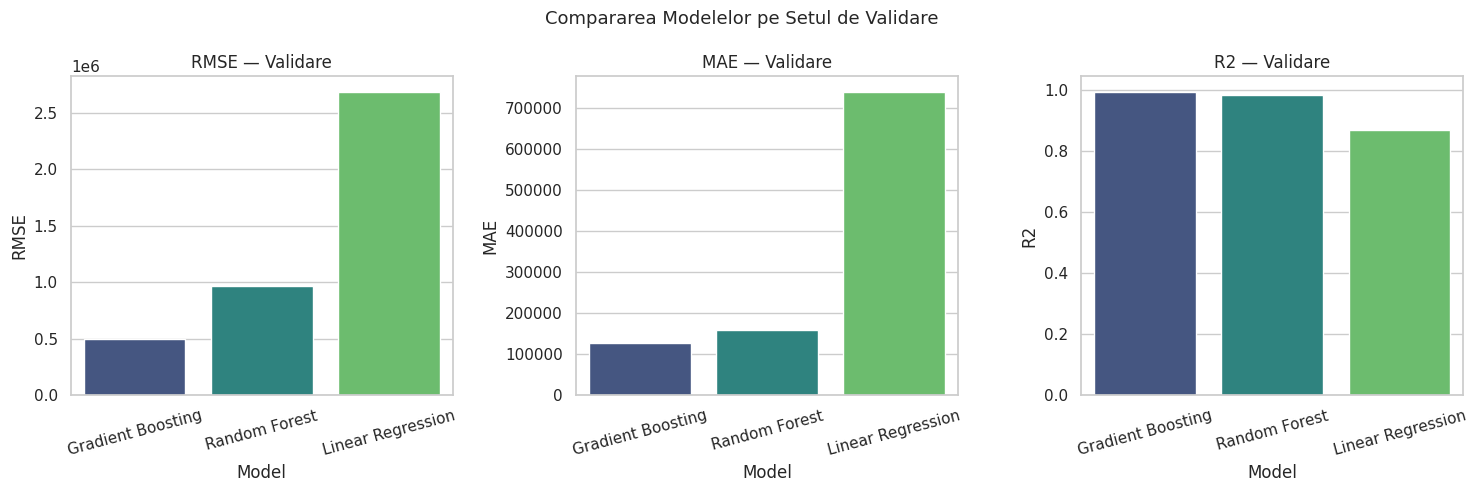

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (metric, asc) in zip(axes, [("RMSE",True),("MAE",True),("R2",False)]):
    data = val_df.sort_values(metric, ascending=asc)
    sns.barplot(data=data, x="Model", y=metric, ax=ax, palette="viridis")
    ax.set_title(f"{metric} — Validare")
    ax.tick_params(axis='x', rotation=15)

plt.suptitle("Compararea Modelelor pe Setul de Validare", fontsize=13)
plt.tight_layout()
plt.show()

### 6.4 Analiza Overfitting/Underfitting — Train vs. Validare (FBD_1)

O eroare mică de antrenament NU garantează performanță bună în realitate.
Diferența mare Train-Validare indică overfitting.
Erori mari pe ambele seturi indică underfitting.

R² — Train vs. Validare:


Set,Train,Validare
Model,,
Gradient Boosting,0.997923,0.995633
Linear Regression,0.902685,0.870100
Random Forest,0.995506,0.983294



RMSE — Train vs. Validare:


Set,Train,Validare
Model,,
Gradient Boosting,3.486539e+05,4.930447e+05
Linear Regression,2.386507e+06,2.689200e+06
Random Forest,5.128484e+05,9.643943e+05


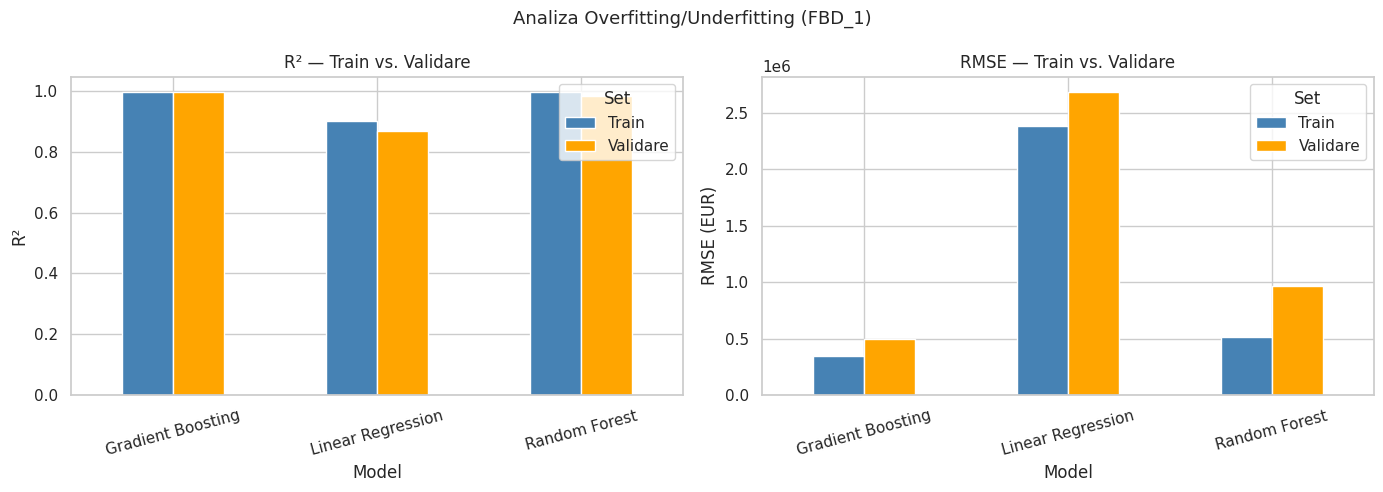

In [40]:
train_val_df = pd.DataFrame([
    linear_train, linear_val,
    rf_train,     rf_val,
    gb_train,     gb_val
])

pivot_r2   = train_val_df.pivot(index="Model", columns="Set", values="R2")
pivot_rmse = train_val_df.pivot(index="Model", columns="Set", values="RMSE")

print("R² — Train vs. Validare:")
display(pivot_r2)
print("\nRMSE — Train vs. Validare:")
display(pivot_rmse)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pivot_r2.plot(kind="bar", ax=axes[0], color=["steelblue","orange"])
axes[0].set_title("R² — Train vs. Validare")
axes[0].set_ylabel("R²")
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(title="Set")

pivot_rmse.plot(kind="bar", ax=axes[1], color=["steelblue","orange"])
axes[1].set_title("RMSE — Train vs. Validare")
axes[1].set_ylabel("RMSE (EUR)")
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(title="Set")

plt.suptitle("Analiza Overfitting/Underfitting (FBD_1)", fontsize=13)
plt.tight_layout()
plt.show()

### 6.5 Alegerea modelului final

Modelul final este ales pe baza RMSE pe setul de VALIDARE.
Setul de test nu a fost atins până în acest moment.

In [41]:
best_name = val_df_sorted.iloc[0]["Model"]

model_registry = {
    "Linear Regression": linear_model,
    "Random Forest":     random_forest_model,
    "Gradient Boosting": gradient_boosting_model
}
best_model_val = model_registry[best_name]

print(f"Modelul final selectat: {best_name}")
print(f"  RMSE validare: {val_df_sorted.iloc[0]['RMSE']:>12,.2f} EUR")
print(f"  R²   validare: {val_df_sorted.iloc[0]['R2']:>12.4f}")
print(f"  Parametri:     {best_gb_params}")

Modelul final selectat: Gradient Boosting
  RMSE validare:   493,044.70 EUR
  R²   validare:       0.9956
  Parametri:     {'learning_rate': 0.1, 'max_depth': 5, 'min_samples_leaf': 5, 'n_estimators': 200}


### 6.6 KDD Pasul 8 — Reantrenarea modelului final pe Train + Validare

Conform procesului KDD, după selectarea celui mai bun model
pe setul de validare, îl reantrenăm pe întregul set de
antrenament disponibil: Train + Validare = 85% din date.
Aceasta maximizează datele de antrenament înainte de
evaluarea finală pe test.

In [42]:
best_model_final = Pipeline(steps=[
    ("preprocessor", create_preprocessor(num_sel, cat_sel)),
    ("model", GradientBoostingRegressor(**best_gb_params, random_state=42))
])

best_model_final.fit(X_trainval_sel, y_trainval)

print(f"Model final reantrenat pe {len(X_trainval_sel)} exemple.")
print(f"  Train:    {len(X_train_sel)} exemple (70%)")
print(f"  Validare: {len(X_val_sel)} exemple (15%)")
print(f"  Total:    {len(X_trainval_sel)} exemple (85%)")
print(f"\nAlgoritm: Gradient Boosting")
print(f"Parametri: {best_gb_params}")

Model final reantrenat pe 16290 exemple.
  Train:    13422 exemple (70%)
  Validare: 2868 exemple (15%)
  Total:    16290 exemple (85%)

Algoritm: Gradient Boosting
Parametri: {'learning_rate': 0.1, 'max_depth': 5, 'min_samples_leaf': 5, 'n_estimators': 200}


## 7. Evaluarea Detaliată pe Setul de Test

### 7.1 Evaluarea finală pe TEST

Setul de test este folosit O SINGURĂ DATĂ, acum.
Modelul evaluat este cel reantrenat pe 85% din date (KDD Pasul 8).
Rezultatele reprezintă performanța reală pe date complet noi.

In [43]:
print("=" * 55)
print("  EVALUARE FINALĂ — Setul de TEST")
print("=" * 55)

linear_test = evaluate_model("Linear Regression", linear_model,
                              X_test_sel, y_test, "Test")
rf_test     = evaluate_model("Random Forest", random_forest_model,
                              X_test_sel, y_test, "Test")
gb_test     = evaluate_model("Gradient Boosting", best_model_final,
                              X_test_sel, y_test, "Test")

test_df = pd.DataFrame([linear_test, rf_test, gb_test])\
          .sort_values("RMSE").reset_index(drop=True)

print("\nComparație finală pe Test:")
display(test_df[["Model", "MAE", "MSE", "RMSE", "R2"]])

  EVALUARE FINALĂ — Setul de TEST

───────────────────────────────────────────────────────
  Linear Regression [Test]
───────────────────────────────────────────────────────
  MAE  :      646,359.60 EUR
  MSE  : 6,066,838,161,465.29 EUR²
  RMSE :    2,463,095.24 EUR
  R²   :          0.8947

───────────────────────────────────────────────────────
  Random Forest [Test]
───────────────────────────────────────────────────────
  MAE  :      175,604.93 EUR
  MSE  : 3,436,129,048,034.54 EUR²
  RMSE :    1,853,679.87 EUR
  R²   :          0.9403

───────────────────────────────────────────────────────
  Gradient Boosting [Test]
───────────────────────────────────────────────────────
  MAE  :      125,233.74 EUR
  MSE  : 767,731,806,312.69 EUR²
  RMSE :      876,203.06 EUR
  R²   :          0.9867

Comparație finală pe Test:


,Model,MAE,MSE,RMSE,R2
0,Gradient Boosting,125233.737698,7.677318e+11,8.762031e+05,0.986672
1,Random Forest,175604.926933,3.436129e+12,1.853680e+06,0.940347
2,Linear Regression,646359.602556,6.066838e+12,2.463095e+06,0.894677


### 7.2 Grafice de evaluare — modelul final

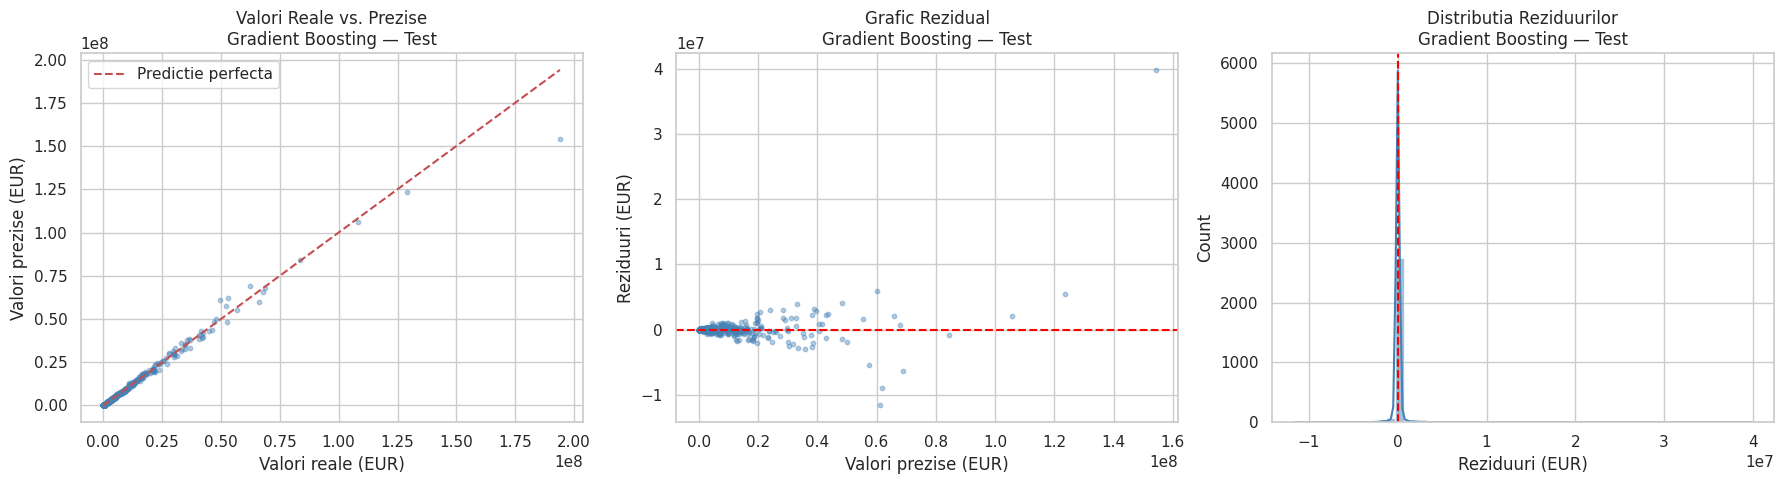

In [44]:
y_pred_log  = best_model_final.predict(X_test_sel)
y_pred_eur  = np.clip(np.expm1(y_pred_log), 0, None)
y_test_eur  = np.expm1(np.array(y_test))
residuals   = y_test_eur - y_pred_eur

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Grafic 1: Valori reale vs. prezise
max_val = max(y_test_eur.max(), y_pred_eur.max())
axes[0].scatter(y_test_eur, y_pred_eur, alpha=0.4, s=10, color="steelblue")
axes[0].plot([0, max_val], [0, max_val], "r--", linewidth=1.5,
             label="Predictie perfecta")
axes[0].set_title("Valori Reale vs. Prezise\nGradient Boosting — Test")
axes[0].set_xlabel("Valori reale (EUR)")
axes[0].set_ylabel("Valori prezise (EUR)")
axes[0].legend()

# Grafic 2: Rezidual
axes[1].scatter(y_pred_eur, residuals, alpha=0.4, s=10, color="steelblue")
axes[1].axhline(0, color="red", linestyle="--", linewidth=1.5)
axes[1].set_title("Grafic Rezidual\nGradient Boosting — Test")
axes[1].set_xlabel("Valori prezise (EUR)")
axes[1].set_ylabel("Reziduuri (EUR)")

# Grafic 3: Distributia reziduurilor
sns.histplot(residuals, bins=50, kde=True,
             color="steelblue", ax=axes[2])
axes[2].axvline(0, color="red", linestyle="--", linewidth=1.5)
axes[2].set_title("Distributia Reziduurilor\nGradient Boosting — Test")
axes[2].set_xlabel("Reziduuri (EUR)")

plt.tight_layout()
plt.show()

### 7.3 QQ-Plot — Verificarea normalității reziduurilor

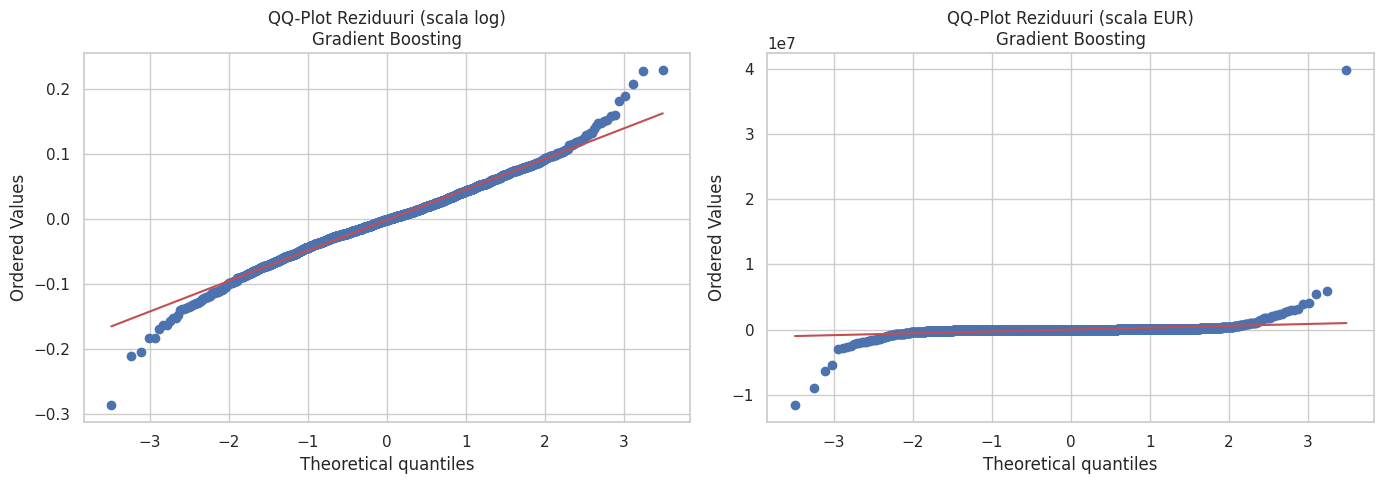

Test Shapiro-Wilk (n=500):
  Statistica W = 0.9901
  p-value      = 0.001962
  Reziduurile nu sunt perfect normale (p <= 0.05)
  Normal pentru seturi mari de date.


In [45]:
residuals_log = np.array(y_test) - best_model_final.predict(X_test_sel)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

stats.probplot(residuals_log, dist="norm", plot=axes[0])
axes[0].set_title("QQ-Plot Reziduuri (scala log)\nGradient Boosting")

stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title("QQ-Plot Reziduuri (scala EUR)\nGradient Boosting")

plt.tight_layout()
plt.show()

shapiro_stat, shapiro_p = stats.shapiro(residuals_log[:500])
print(f"Test Shapiro-Wilk (n=500):")
print(f"  Statistica W = {shapiro_stat:.4f}")
print(f"  p-value      = {shapiro_p:.6f}")
if shapiro_p > 0.05:
    print("  Reziduurile sunt aproximativ normale (p > 0.05)")
else:
    print("  Reziduurile nu sunt perfect normale (p <= 0.05)")
    print("  Normal pentru seturi mari de date.")

### 7.4 Importanța variabilelor — modelul final

/tmp/ipykernel_1583/3593345234.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp_final_df, x="Importanta",


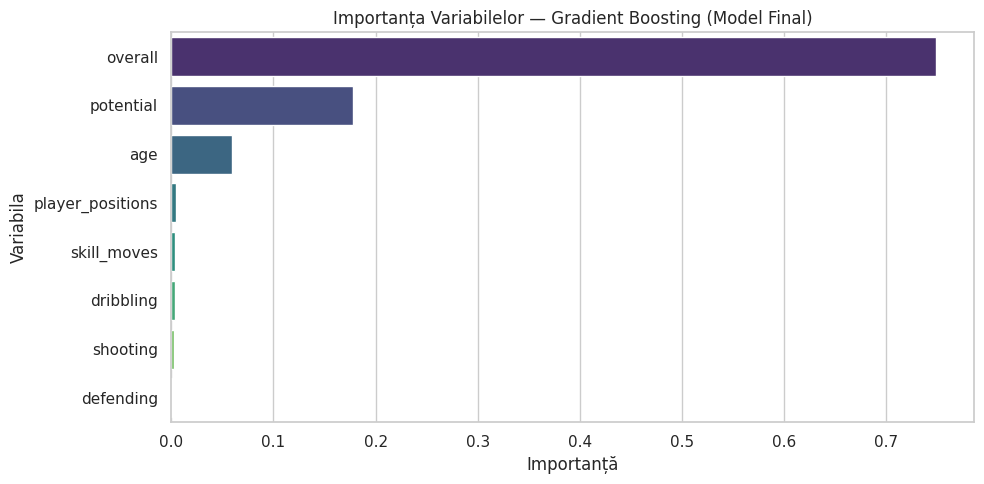

,Variabila,Importanta
0,overall,0.748328
1,potential,0.177415
2,age,0.059096
3,player_positions,0.004509
4,skill_moves,0.003664
5,dribbling,0.003614
6,shooting,0.002720
7,defending,0.000654


In [46]:
enc_names_final = best_model_final.named_steps["preprocessor"].get_feature_names_out()
imp_final       = best_model_final.named_steps["model"].feature_importances_

agg_imp_final = {}
for enc_name, imp in zip(enc_names_final, imp_final):
    orig = get_original_feature(enc_name, num_sel, cat_sel)
    agg_imp_final[orig] = agg_imp_final.get(orig, 0) + imp

feat_imp_final_df = pd.DataFrame({
    "Variabila":  list(agg_imp_final.keys()),
    "Importanta": list(agg_imp_final.values())
}).sort_values("Importanta", ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 5))
sns.barplot(data=feat_imp_final_df, x="Importanta",
            y="Variabila", palette="viridis")
plt.title("Importanța Variabilelor — Gradient Boosting (Model Final)")
plt.xlabel("Importanță")
plt.tight_layout()
plt.show()

display(feat_imp_final_df)

### 7.5 Top 10 cele mai mari erori de predicție

In [47]:
error_df = X_test_sel.copy()
error_df["Actual_EUR"]     = y_test_eur
error_df["Predicted_EUR"]  = y_pred_eur
error_df["Absolute_Error"] = np.abs(y_test_eur - y_pred_eur)
error_df = error_df.sort_values("Absolute_Error", ascending=False)

cols_show = [c for c in
    ["overall", "potential", "age", "player_positions",
     "Actual_EUR", "Predicted_EUR", "Absolute_Error"]
    if c in error_df.columns]

print("Top 10 cele mai mari erori de predicție:")
display(error_df[cols_show].head(10))

Top 10 cele mai mari erori de predicție:


,overall,potential,age,player_positions,Actual_EUR,Predicted_EUR,Absolute_Error
6,91,95,22,"ST, LW",194000000.0,1.541776e+08,3.982245e+07
127,84,89,25,GK,49500000.0,6.112945e+07,1.162945e+07
197,83,89,22,CB,53000000.0,6.195443e+07,8.954428e+06
137,84,90,23,LB,62500000.0,6.885829e+07,6.358294e+06
35,87,87,31,"CAM, RM, RW",66000000.0,6.007852e+07,5.921485e+06
3,91,91,29,"LW, CAM",129000000.0,1.235454e+08,5.454595e+06
130,84,88,26,CB,52000000.0,5.740859e+07,5.408589e+06
88,85,85,29,"CM, CDM",52500000.0,4.834307e+07,4.156927e+06
183,83,83,28,ST,37000000.0,3.299801e+07,4.001989e+06
34,87,87,31,GK,42000000.0,3.887079e+07,3.129214e+06


### 7.6 Comparare finală: Validare vs. Test

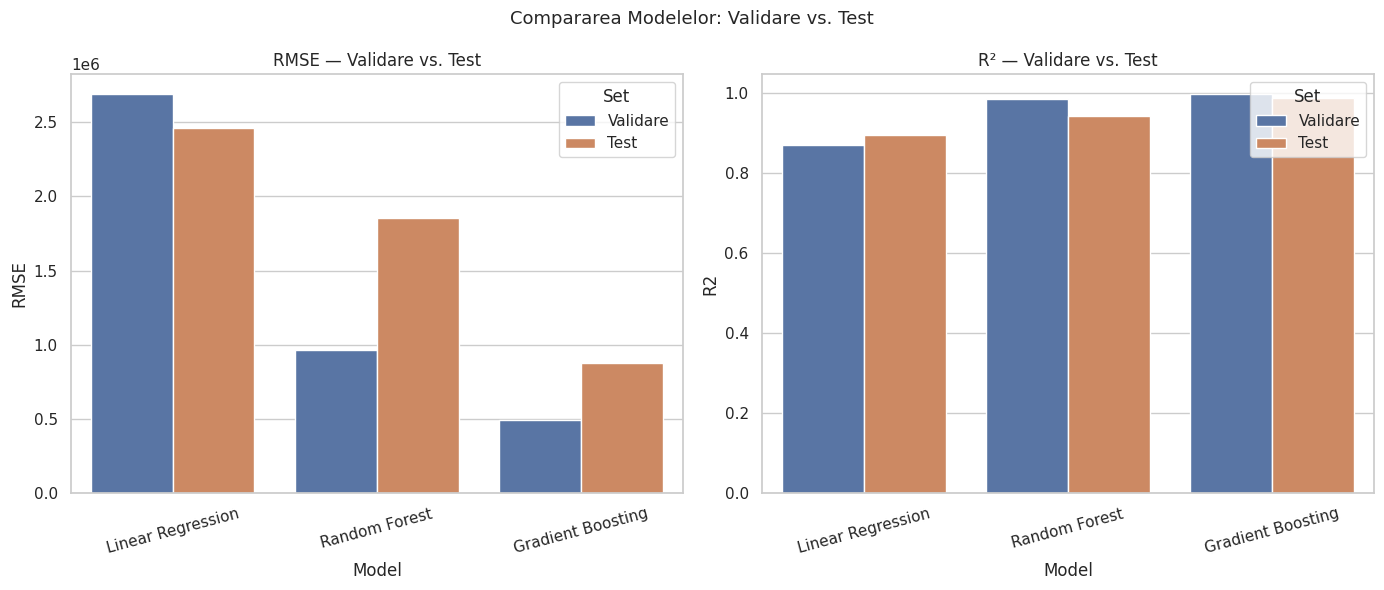

In [48]:
all_results = pd.concat([val_df, test_df], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(data=all_results, x="Model", y="RMSE",
            hue="Set", ax=axes[0])
axes[0].set_title("RMSE — Validare vs. Test")
axes[0].tick_params(axis='x', rotation=15)

sns.barplot(data=all_results, x="Model", y="R2",
            hue="Set", ax=axes[1])
axes[1].set_title("R² — Validare vs. Test")
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle("Compararea Modelelor: Validare vs. Test", fontsize=13)
plt.tight_layout()
plt.show()

## 8. Concluzii, Limitări și Aplicații

### 8.1 Tabel final cu toate modelele pe Test

In [49]:
final_display = test_df[["Model", "MAE", "MSE", "RMSE", "R2"]].copy()
final_display["MAE"]  = final_display["MAE"].apply(lambda x: f"{x:>12,.0f} EUR")
final_display["MSE"]  = final_display["MSE"].apply(lambda x: f"{x:>12,.0f} EUR²")
final_display["RMSE"] = final_display["RMSE"].apply(lambda x: f"{x:>12,.0f} EUR")
final_display["R2"]   = final_display["R2"].apply(lambda x: f"{x:.4f}")

print("Performanța modelelor pe setul de TEST:")
display(final_display)

Performanța modelelor pe setul de TEST:


,Model,MAE,MSE,RMSE,R2
0,Gradient Boosting,"125,234 EUR","767,731,806,313 EUR²","876,203 EUR",0.9867
1,Random Forest,"175,605 EUR","3,436,129,048,035 EUR²","1,853,680 EUR",0.9403
2,Linear Regression,"646,360 EUR","6,066,838,161,465 EUR²","2,463,095 EUR",0.8947


### 8.2 Interpretarea rezultatelor și variabilele cheie

**Cel mai bun model: Gradient Boosting**
- R² = 0.9867 — modelul explică 98.7% din varianța valorilor de piață
- MAE = 125.233 EUR — eroarea medie absolută
- RMSE = 876.203 EUR — erori mai mari pentru jucătorii foarte valoroși

**Variabilele cheie identificate (selecție din secțiunea 4):**
- `overall` (~75%) — ratingul FIFA general este cel mai puternic predictor
- `potential` (~18%) — jucătorii tineri cu potențial ridicat sunt mai valoroși
- `age` (~5%) — la același overall, jucătorii mai tineri valorează mai mult
- `player_positions`, `skill_moves`, `shooting`, `dribbling`, `defending`
  — contribuție individuală mică dar relevantă

**Ecuația regresiei liniare (model baseline):**
log1p(value_eur) = 13.9064 + (1.2986)·overall + (-0.5558)·age + ...
Coeficientul overall = 1.2986: fiecare punct în plus la overall
crește log1p(value_eur) cu ~1.30 unități logaritmice.

### 8.3 Compararea modelelor

| Model | MAE | RMSE | R² |
|---|---|---|---|
| Gradient Boosting | 125.233 EUR | 876.203 EUR | 0.9867 |
| Random Forest | 175.604 EUR | 1.853.679 EUR | 0.9403 |
| Linear Regression | 646.359 EUR | 2.463.095 EUR | 0.8947 |

Gradient Boosting > Random Forest > Linear Regression pe toate metricile.
Gradient Boosting reduce bias-ul prin construcție secvențială (FBD_4),
spre deosebire de Random Forest care reduce varianța (construcție paralelă).

### 8.4 Puncte forte
- Acuratețe ridicată pentru jucători cu valoare medie (sub 50M EUR)
- Model consistent între validare și test — fără overfitting major
- Transformarea log1p îmbunătățește semnificativ performanța
- Hiperparametri optimi identificați prin GridSearchCV
- Early stopping confirmă că 81 iterații sunt suficiente pentru GB

### 8.5 Limitări
- Erori mari pentru jucătorii cu valoare extremă (Mbappé, Haaland)
- Factori externi neincluși: formă recentă, accidentări, agent,
  popularitate pe social media, context de transfer
- Dataset FIFA 22 — ratingurile sunt subiective, evaluate de EA Sports
- Modelul nu surprinde evoluția temporală a valorilor

### 8.6 Aplicații potențiale
- Asistarea cluburilor în negocieri de transfer
- Identificarea jucătorilor subapreciați (scouting)
- Analiza riscului financiar pentru investiții în jucători

In [50]:
test_df.to_csv("rezultate_modele_fifa22.csv", index=False)
error_df[cols_show].head(20).to_csv("erori_mari_fifa22.csv", index=False)

best_row = test_df.iloc[0]
print(f"""
Model final: {best_row['Model']}
Parametri:   {best_gb_params}

Performanta pe setul de TEST:
  MAE  = {best_row['MAE']:>12,.0f} EUR
  MSE  = {best_row['MSE']:>12,.0f} EUR²
  RMSE = {best_row['RMSE']:>12,.0f} EUR
  R²   = {best_row['R2']:>12.4f}

Fisiere salvate:
  - rezultate_modele_fifa22.csv
  - erori_mari_fifa22.csv
""")


Model final: Gradient Boosting
Parametri:   {'learning_rate': 0.1, 'max_depth': 5, 'min_samples_leaf': 5, 'n_estimators': 200}

Performanta pe setul de TEST:
  MAE  =      125,234 EUR
  MSE  = 767,731,806,313 EUR²
  RMSE =      876,203 EUR
  R²   =       0.9867

Fisiere salvate:
  - rezultate_modele_fifa22.csv
  - erori_mari_fifa22.csv

